In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.optimize import curve_fit

In [2]:
# ==================== Control Variables ====================
num_rc = 4                      # number of RC pairs in the ladder
Aw = 0.05                       # Warburg coefficient (Ohm * s^-0.5)
dt = 0.001                      # simulation time step (s)
freqs = np.logspace(-1, 2, 40)  # frequency sweep (Hz): used for fitting, Nyquist, and error plots
# ==============================================================

omega_fit = 2 * np.pi * freqs

# Ideal continuous Warburg impedance target: Z = Aw / sqrt(j*omega)
Z_warburg_ideal = Aw / np.sqrt(1j * omega_fit)

def rc_ladder_impedance(omega, *params):
    R = np.array(params[:num_rc])
    C = np.array(params[num_rc:])
    Z = np.zeros(len(omega), dtype=complex)
    for R_i, C_i in zip(R, C):
        Z_cdl = 1 / (1j * omega * C_i)
        Z += (R_i * Z_cdl) / (R_i + Z_cdl)
    return Z

def _rc_ladder_stacked(omega, *params):
    # curve_fit needs a real-valued residual vector, so stack real/imag parts
    Z = rc_ladder_impedance(omega, *params)
    return np.concatenate([Z.real, Z.imag])

target_stacked = np.concatenate([Z_warburg_ideal.real, Z_warburg_ideal.imag])

# Initial guess (log-spaced time constants) just to seed the optimizer
tau_guess = np.logspace(-2, 1, num_rc)
R_guess = Aw * np.sqrt(tau_guess)
C_guess = tau_guess / R_guess
p0 = np.concatenate([R_guess, C_guess])

popt, _ = curve_fit(_rc_ladder_stacked, omega_fit, target_stacked, p0=p0, bounds=(0, np.inf), maxfev=20000)
R_arr = popt[:num_rc]
C_arr = popt[num_rc:]
tau_arr = R_arr * C_arr

print(f"Fit {num_rc} RC circuits in series to match the ideal Warburg impedance (Aw={Aw}).")
print(f"Resistors (Ohms): {np.round(R_arr, 4)}")
print(f"Capacitors (Farads): {np.round(C_arr, 3)}")

Fit 4 RC circuits in series to match the ideal Warburg impedance (Aw=0.05).
Resistors (Ohms): [0.0035 0.0088 0.0211 0.1323]
Capacitors (Farads): [ 0.803  6.041 21.324 36.196]


In [3]:
def model_exact(R_arr, C_arr, I_signal, dt):
    n = len(I_signal)
    num_rc = len(R_arr)
    
    V_c = np.zeros((num_rc, n)) # A grid to hold voltages for our 4 capacitors
    V_tot = np.zeros(n)         # The final added-up voltage
    
    alpha = np.exp(-dt / (R_arr * C_arr))
    
    for k in range(1, n):
        # VECTORIZED: Calculates all 4 capacitors at the exact same time!
        V_c[:, k] = alpha * V_c[:, k-1] + (1 - alpha) * I_signal[k] * R_arr
        
        # Add the 4 capacitor voltages together!
        V_tot[k] = np.sum(V_c[:, k])
    return V_tot

def model_euler(R_arr, C_arr, I_signal, dt):
    n = len(I_signal)
    num_rc = len(R_arr)
    V_c = np.zeros((num_rc, n))
    V_tot = np.zeros(n)
    
    for k in range(1, n):
        # VECTORIZED: Computes slopes and updates all 4 capacitors instantly
        dVc = (I_signal[k-1] - V_c[:, k-1] / R_arr) / C_arr
        V_c[:, k] = V_c[:, k-1] + dt * dVc
            
        V_tot[k] = np.sum(V_c[:, k])
    return V_tot

def model_rk4(R_arr, C_arr, I_signal, dt):
    # Interpolated-input RK4: classical RK4 needs the forcing at t, t+dt/2, t+dt/2, t+dt.
    # We only ever sample I at t (I_signal[k-1]) and t+dt (I_signal[k]), so the midpoint
    # value is a linear interpolation between them instead of assuming I is frozen for
    # the whole step (which is what plain ZOH-input RK4 does).
    n = len(I_signal)
    num_rc = len(R_arr)
    V_c = np.zeros((num_rc, n))
    V_tot = np.zeros(n)
    
    def dVc(Vc, I, R, C):
        return (I - Vc / R) / C

    for k in range(1, n):
        I_prev = I_signal[k-1]
        I_next = I_signal[k]
        I_mid = 0.5 * (I_prev + I_next)

        # VECTORIZED: RK4 calculated simultaneously for all 4 pairs
        k1 = dVc(V_c[:, k-1], I_prev, R_arr, C_arr)
        k2 = dVc(V_c[:, k-1] + dt/2 * k1, I_mid, R_arr, C_arr)
        k3 = dVc(V_c[:, k-1] + dt/2 * k2, I_mid, R_arr, C_arr)
        k4 = dVc(V_c[:, k-1] + dt * k3, I_next, R_arr, C_arr)
        
        V_c[:, k] = V_c[:, k-1] + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
            
        V_tot[k] = np.sum(V_c[:, k])
    return V_tot

In [4]:
Z_real_exact, Z_imag_exact = [], []
Z_real_rk4, Z_imag_rk4 = [], []
Z_real_euler, Z_imag_euler = [], []

for f in freqs:
    # Warmup uses the slowest RC time constant in the fitted ladder
    t_warmup = 3 * np.max(tau_arr)
    t_signal = 10 / f         
    
    n_warmup = int(t_warmup / dt)
    n_signal = int(t_signal / dt)
    
    n_total = n_warmup + n_signal
    t_full = np.arange(n_total) * dt
    
    omega = 2 * np.pi * f
    I_full = np.sin(omega * t_full)
    
    def extract_Z(V_sweep, I_sweep, f):
        V_clean = V_sweep[n_warmup:]
        I_clean = I_sweep[n_warmup:]
        N = len(V_clean)
        
        V_fft = np.fft.fft(V_clean)
        I_fft = np.fft.fft(I_clean)
        freqs_fft = np.fft.fftfreq(N, dt) 
        
        idx = np.argmin(np.abs(freqs_fft - f))
        Z = V_fft[idx] / I_fft[idx]
        return Z.real, -Z.imag

    V_e = model_exact(R_arr, C_arr, I_full, dt)
    zr, zi = extract_Z(V_e, I_full, f)
    Z_real_exact.append(zr)
    Z_imag_exact.append(zi)

    V_r = model_rk4(R_arr, C_arr, I_full, dt)
    zr, zi = extract_Z(V_r, I_full, f)
    Z_real_rk4.append(zr)
    Z_imag_rk4.append(zi)

    V_eu = model_euler(R_arr, C_arr, I_full, dt)
    zr, zi = extract_Z(V_eu, I_full, f)
    Z_real_euler.append(zr)
    Z_imag_euler.append(zi)

In [5]:
def freq_domain_rc_ladder(freqs, R_arr, C_arr):
    omega = 2 * np.pi * freqs
    Z_tot = np.zeros(len(freqs), dtype=complex)
    
    # Add the impedance of the 4 circuits together
    for R, C in zip(R_arr, C_arr):
        Z_cdl = 1 / (1j * omega * C)
        Z_tot += (R * Z_cdl) / (R + Z_cdl)
    return Z_tot

Z_freq = freq_domain_rc_ladder(freqs, R_arr, C_arr)


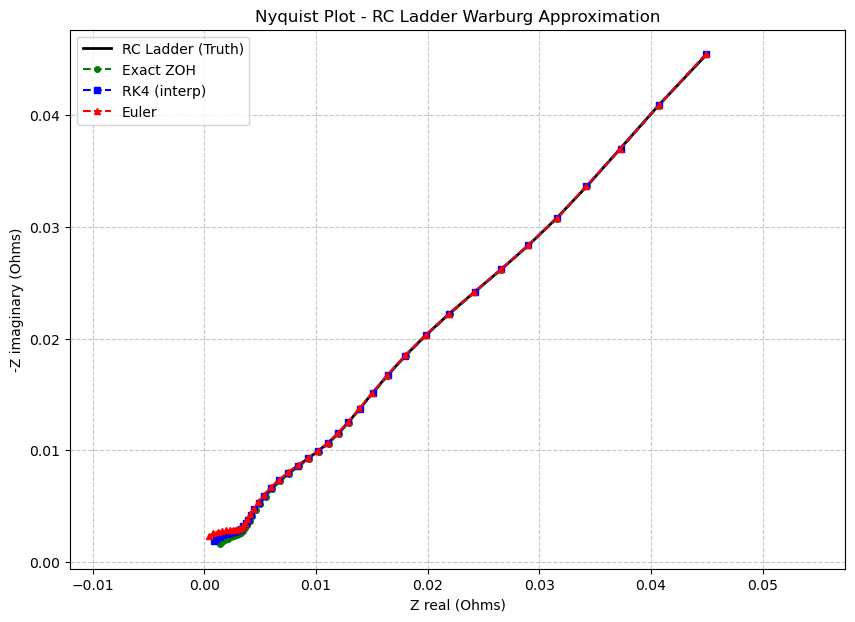

In [6]:
plt.figure(figsize=(10, 7))
plt.plot(Z_freq.real, -Z_freq.imag, 'k-', linewidth=2, label='RC Ladder (Truth)')
plt.plot(Z_real_exact, Z_imag_exact, 'g--o', markersize=4, label='Exact ZOH')
plt.plot(Z_real_rk4, Z_imag_rk4, 'b--s', markersize=4, label='RK4 (interp)')
plt.plot(Z_real_euler, Z_imag_euler, 'r--^', markersize=4, label='Euler')
plt.xlabel('Z real (Ohms)')
plt.ylabel('-Z imaginary (Ohms)')
plt.title('Nyquist Plot - RC Ladder Warburg Approximation')
plt.axis('equal') 
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

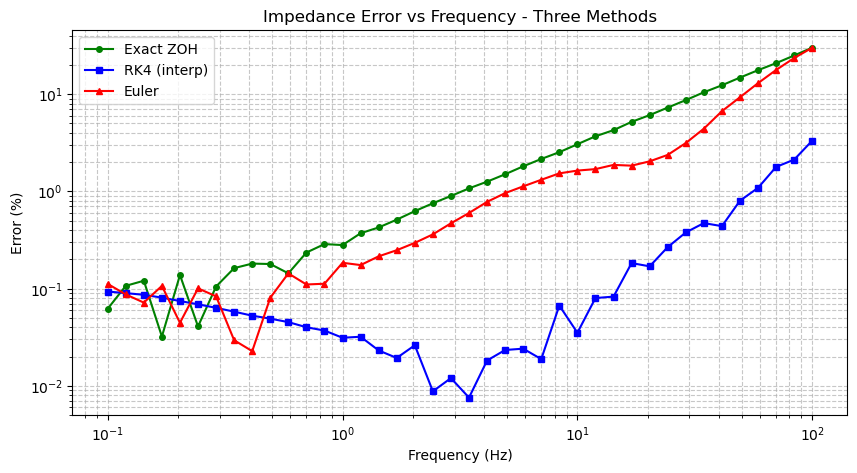

Exact ZOH     : mean=4.630%  max=30.066%  (at 100.00 Hz)
RK4 (interp)  : mean=0.309%  max=3.321%  (at 100.00 Hz)
Euler         : mean=3.213%  max=30.015%  (at 100.00 Hz)


In [7]:
Z_exact_arr = np.array(Z_real_exact) - 1j * np.array(Z_imag_exact)
Z_rk4_arr = np.array(Z_real_rk4) - 1j * np.array(Z_imag_rk4)
Z_euler_arr = np.array(Z_real_euler) - 1j * np.array(Z_imag_euler)

def error_pct(Z_sim, Z_ref):
    # How far off each method's impedance is from the true value, as a % of the true value
    return np.abs(Z_sim - Z_ref) / np.abs(Z_ref) * 100

plt.figure(figsize=(10, 5))
plt.loglog(freqs, error_pct(Z_exact_arr, Z_freq), 'g-o', markersize=4, label='Exact ZOH')
plt.loglog(freqs, error_pct(Z_rk4_arr, Z_freq), 'b-s', markersize=4, label='RK4 (interp)')
plt.loglog(freqs, error_pct(Z_euler_arr, Z_freq), 'r-^', markersize=4, label='Euler')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Error (%)')
plt.title('Impedance Error vs Frequency - Three Methods')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

for name, Z_arr in [('Exact ZOH', Z_exact_arr), ('RK4 (interp)', Z_rk4_arr), ('Euler', Z_euler_arr)]:
    e = error_pct(Z_arr, Z_freq)
    print(f"{name:14s}: mean={e.mean():.3f}%  max={e.max():.3f}%  (at {freqs[np.argmax(e)]:.2f} Hz)")